In [1]:
# Import original dataset

import pandas as pd

df = pd.read_csv("Invistico_Airline.csv")

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129880 non-null  object 
 1   Gender                             129880 non-null  object 
 2   Customer Type                      129880 non-null  object 
 3   Age                                129880 non-null  int64  
 4   Type of Travel                     129880 non-null  object 
 5   Class                              129880 non-null  object 
 6   Flight Distance                    129880 non-null  int64  
 7   Seat comfort                       129880 non-null  int64  
 8   Departure/Arrival time convenient  129880 non-null  int64  
 9   Food and drink                     129880 non-null  int64  
 10  Gate location                      129880 non-null  int64  
 11  Inflight wifi service              1298

In [2]:
df.head()

,satisfaction,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Female,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Male,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Female,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Female,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Female,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,...,4,2,2,0,2,4,2,5,0,0.0


In [3]:
# Step 1: Validate and inspect data types

print("Data Types:")
print(df.dtypes)

Data Types:
satisfaction                          object
Gender                                object
Customer Type                         object
Age                                    int64
Type of Travel                        object
Class                                 object
Flight Distance                        int64
Seat comfort                           int64
Departure/Arrival time convenient      int64
Food and drink                         int64
Gate location                          int64
Inflight wifi service                  int64
Inflight entertainment                 int64
Online support                         int64
Ease of Online booking                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Cleanliness                            int64
Online boarding                        int64
Departure Delay in Minutes             int6

In [4]:
# Step 2: Find missing values

print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
satisfaction                           0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Seat comfort                           0
Departure/Arrival time convenient      0
Food and drink                         0
Gate location                          0
Inflight wifi service                  0
Inflight entertainment                 0
Online support                         0
Ease of Online booking                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Cleanliness                            0
Online boarding                        0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
dtype: int64


In [5]:
# Step 3: Standardize text data (all object/categorical columns)

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.lower().str.strip()

print("Step 3: After text standardization:")
print(df.head())

Step 3: After text standardization:
  satisfaction  Gender   Customer Type  Age   Type of Travel     Class  \
0    satisfied  female  loyal customer   65  personal travel       eco   
1    satisfied    male  loyal customer   47  personal travel  business   
2    satisfied  female  loyal customer   15  personal travel       eco   
3    satisfied  female  loyal customer   60  personal travel       eco   
4    satisfied  female  loyal customer   70  personal travel       eco   

   Flight Distance  Seat comfort  Departure/Arrival time convenient  \
0              265             0                                  0   
1             2464             0                                  0   
2             2138             0                                  0   
3              623             0                                  0   
4              354             0                                  0   

   Food and drink  ...  Online support  Ease of Online booking  \
0               0  ...    

In [6]:
# Step 4: Binary encode 'satisfaction' column (creates a new column)

if 'satisfaction' in df.columns:
    df['satisfaction'] = df['satisfaction'].map({'satisfied': 1, 'dissatisfied': 0})

print("Step 4: After binary encoding 'satisfaction':")
print(df['satisfaction'].head())

Step 4: After binary encoding 'satisfaction':
0    1
1    1
2    1
3    1
4    1
Name: satisfaction, dtype: int64


In [7]:
# Step 5: One-hot encode all remaining categorical (object) columns

# Columns you want to keep as original (exclude from one-hot encoding)
exclude_categorical = ['Gender', 'Type of Travel']

# Identify which object columns to encode
cat_cols_to_encode = [col for col in df.select_dtypes(include='object').columns if col not in exclude_categorical]

# Only apply get_dummies to selected cols (others remain unchanged)
df_encoded = pd.get_dummies(df, columns=cat_cols_to_encode, drop_first=True)

print("Step 5: After one-hot encoding:")
print(df_encoded.head())

Step 5: After one-hot encoding:
   satisfaction  Gender  Age   Type of Travel  Flight Distance  Seat comfort  \
0             1  female   65  personal travel              265             0   
1             1    male   47  personal travel             2464             0   
2             1  female   15  personal travel             2138             0   
3             1  female   60  personal travel              623             0   
4             1  female   70  personal travel              354             0   

   Departure/Arrival time convenient  Food and drink  Gate location  \
0                                  0               0              2   
1                                  0               0              3   
2                                  0               0              3   
3                                  0               0              3   
4                                  0               0              3   

   Inflight wifi service  ...  Leg room service  Baggage han

In [8]:
# Step 5: One-hot encode all remaining categorical (object) columns

# Columns you want to keep as original (exclude from one-hot encoding)
exclude_categorical = ['Gender', 'Type of Travel']

# Identify which object columns to encode
cat_cols_to_encode = [col for col in df.select_dtypes(include='object').columns if col not in exclude_categorical]

# Only apply get_dummies to selected cols (others remain unchanged)
df_encoded = pd.get_dummies(df, columns=cat_cols_to_encode, drop_first=True)

print("Step 5: After one-hot encoding:")
print(df_encoded.head())


Step 5: After one-hot encoding:
   satisfaction  Gender  Age   Type of Travel  Flight Distance  Seat comfort  \
0             1  female   65  personal travel              265             0   
1             1    male   47  personal travel             2464             0   
2             1  female   15  personal travel             2138             0   
3             1  female   60  personal travel              623             0   
4             1  female   70  personal travel              354             0   

   Departure/Arrival time convenient  Food and drink  Gate location  \
0                                  0               0              2   
1                                  0               0              3   
2                                  0               0              3   
3                                  0               0              3   
4                                  0               0              3   

   Inflight wifi service  ...  Leg room service  Baggage han

In [9]:
# Step 5: Convert boolean columns to 1/0 if present

to_convert = ['Customer Type_loyal customer', 'Class_eco', 'Class_eco plus']
for col in to_convert:
    if col in df_encoded.columns:
        df_encoded[col] = df_encoded[col].astype(int)

print(df_encoded.head())

   satisfaction  Gender  Age   Type of Travel  Flight Distance  Seat comfort  \
0             1  female   65  personal travel              265             0   
1             1    male   47  personal travel             2464             0   
2             1  female   15  personal travel             2138             0   
3             1  female   60  personal travel              623             0   
4             1  female   70  personal travel              354             0   

   Departure/Arrival time convenient  Food and drink  Gate location  \
0                                  0               0              2   
1                                  0               0              3   
2                                  0               0              3   
3                                  0               0              3   
4                                  0               0              3   

   Inflight wifi service  ...  Leg room service  Baggage handling  \
0                      

In [10]:
''' # Step 5: Outlier detection and removal using raw numeric columns (optional)
import numpy as np

numeric_cols = df_encoded.select_dtypes(include='number').columns
outlier_cols = []

for col in numeric_cols:
    mean = df_encoded[col].mean()
    std = df_encoded[col].std()
    outlier_flag = (np.abs(df_encoded[col] - mean) > 3 * std)
    if outlier_flag.sum() > 0:
        outlier_cols.append(col)
    # Mark rows for removal if any value in numeric columns is an outlier
    if 'outlier_any' in df_encoded:
        df_encoded['outlier_any'] = df_encoded['outlier_any'] | outlier_flag
    else:
        df_encoded['outlier_any'] = outlier_flag

if 'outlier_any' in df_encoded.columns:
    outlier_count = df_encoded['outlier_any'].sum()
    if outlier_count > 0:
        print(f"Outliers detected in {', '.join(outlier_cols)}. Removing {outlier_count} rows.")
        df_encoded = df_encoded[~df_encoded['outlier_any']].drop(columns='outlier_any').reset_index(drop=True)
    else:
        print("No outliers detected; no rows removed.")
else:
    print("No outlier columns found.")
'''

########
import numpy as np
from scipy import stats

# Assume df_encoded is your dataframe ready after one-hot encoding and column adjustments

# Step 6: Outlier detection and removal using original numeric columns (show before & after)
numeric_cols = df_encoded.select_dtypes(include='number').columns

# --- Display dataset BEFORE outlier removal ---
print("\nDataset BEFORE outlier removal:")
print(df_encoded.head())
print(f"Shape before: {df_encoded.shape}")

# Compute z-score for each value in numeric columns
z_scores = np.abs(stats.zscore(df_encoded[numeric_cols], nan_policy='omit')) # shape: (rows, numeric_cols)

# Find rows where ALL numeric values are within 3 std (axis=1)
mask = (z_scores < 3).all(axis=1)

# Optionally, print how many outliers per column (for info)
outlier_info = (~(z_scores < 3)).sum(axis=0)
print("\nOutliers per column (values > 3 std):")
print(dict(zip(numeric_cols, outlier_info)))

# Display how many rows will be removed
num_rows_removed = (~mask).sum()
print(f"\nNumber of rows to be removed as outliers: {num_rows_removed}")

# Remove outlier rows
cleaned_df_encoded = df_encoded[mask].reset_index(drop=True)

# --- Display dataset AFTER outlier removal ---
print("\nDataset AFTER outlier removal:")
print(cleaned_df_encoded.head())
print(f"Shape after: {cleaned_df_encoded.shape}")



Dataset BEFORE outlier removal:
   satisfaction  Gender  Age   Type of Travel  Flight Distance  Seat comfort  \
0             1  female   65  personal travel              265             0   
1             1    male   47  personal travel             2464             0   
2             1  female   15  personal travel             2138             0   
3             1  female   60  personal travel              623             0   
4             1  female   70  personal travel              354             0   

   Departure/Arrival time convenient  Food and drink  Gate location  \
0                                  0               0              2   
1                                  0               0              3   
2                                  0               0              3   
3                                  0               0              3   
4                                  0               0              3   

   Inflight wifi service  ...  Leg room service  Baggage ha

In [11]:
# Save the cleaned dataframe

cleaned_df_encoded.to_csv("Invistico_Airline_cleaned.csv", index=False)
print('Cleaned dataset saved as Invistico_Airline_cleaned.csv.')

Cleaned dataset saved as Invistico_Airline_cleaned.csv.


**My part starts here: Investigate how different service aspects influence passengers’ likelihood to choose a higher class (EcoPlus or Business).**

In [31]:
#Create the “upgrade” variable -> upgrade = 1
df['upgrade'] = df['Class'].isin(['eco plus', 'business']).astype(int)
print(df['upgrade'].value_counts())
# Percentage of upgrade = 1
upgrade_percent = df['upgrade'].mean() * 100
print(f"\nPercentage of upgraded passengers: {upgrade_percent:.2f}%")

"""
There are 55.11% chose to upgrade
"""

upgrade
1    71571
0    58309
Name: count, dtype: int64

Percentage of upgraded passengers: 55.11%


Seat comfort                 -0.023528
Arrival Delay in Minutes     -0.012301
Departure Delay in Minutes   -0.008775
Food and drink                0.046908
Inflight wifi service         0.055314
Online boarding               0.087035
Cleanliness                   0.097146
Baggage handling              0.101567
Leg room service              0.110154
Ease of Online booking        0.115284
On-board service              0.138606
Online support                0.159505
Inflight entertainment        0.218458
Name: upgrade, dtype: float64


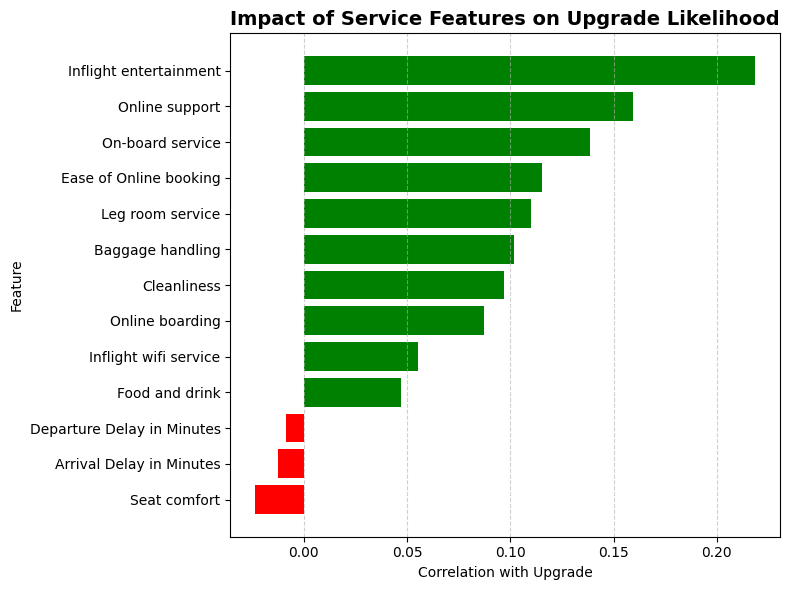

In [35]:
#Feature Correlations with Upgrade Likelihood

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm


# Compute correlations
corr = df.select_dtypes(include='number').corr()['upgrade'].sort_values(ascending=False)

# Pick key features that exist
key_features = [
    'Seat comfort','Inflight entertainment','Food and drink',
    'Inflight wifi service','Online support','Ease of Online booking',
    'Online boarding','On-board service','Leg room service',
    'Baggage handling','Cleanliness',
    'Arrival Delay in Minutes','Departure Delay in Minutes'
]

feat = [c for c in key_features if c in df.columns]

# Extract only the correlations for the selected features
corr_subset = corr[feat].sort_values()
print(corr_subset)

# Plot as horizontal bar chart
plt.figure(figsize=(8, 6))
plt.barh(
    corr_subset.index,
    corr_subset.values,
    color=['green' if v > 0 else 'red' for v in corr_subset.values]
)

plt.title("Impact of Service Features on Upgrade Likelihood", fontsize=14, weight='bold')
plt.xlabel("Correlation with Upgrade")
plt.ylabel("Feature")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

"""
Summary:
Passengers are most likely to upgrade when high-value service features perform well.
The strongest positive drivers of upgrade likelihood are inflight entertainment,
online support, onboard service quality, ease of online booking, and legroom comfort.
These reflect the importance of digital experience, cabin service, and perceived
comfort enhancements. Operational factors such as seat comfort and delays show weak
negative correlations, indicating they affect satisfaction but do not significantly
motivate upgrade decisions. Improving digital touchpoints and highlighting comfort
and service benefits can effectively increase upgrade uptake.
"""


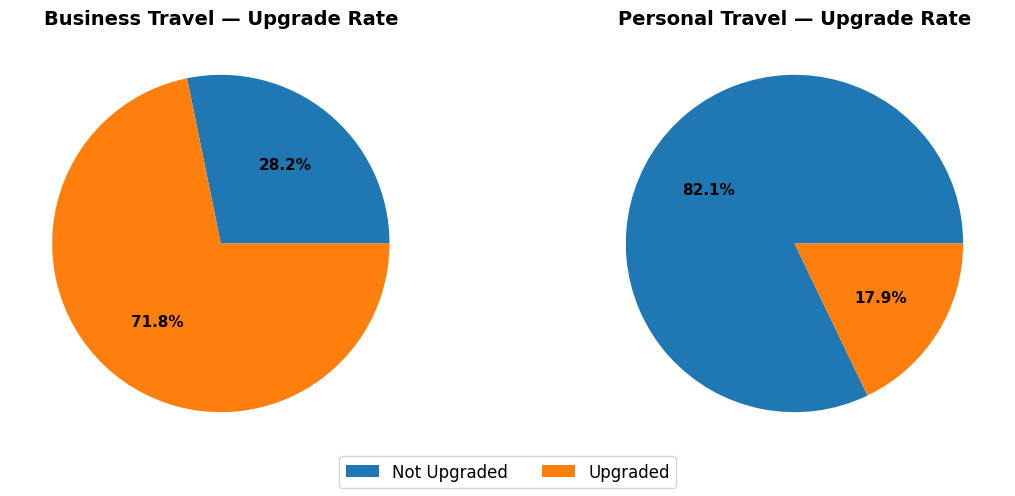

In [39]:
import matplotlib.pyplot as plt

# Choose a nicer color palette (not pastel, clean + bold)
colors = ['#1f77b4', '#ff7f0e']   # blue = no upgrade, orange = upgrade

travel_groups = ['business travel', 'personal travel']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, travel_type in enumerate(travel_groups):
    sizes = df[df['Type of Travel']==travel_type]['upgrade'].value_counts(normalize=True)

    # Ensure the order is always [0,1]
    sizes = sizes.reindex([0,1], fill_value=0)

    axes[i].pie(
        sizes,
        autopct='%1.1f%%',
        colors=colors,
        textprops={'fontsize': 11, 'weight': 'bold'}
    )
    axes[i].set_title(f"{travel_type.title()} — Upgrade Rate", fontsize=14, weight='bold')

# Add a shared legend
fig.legend(
    ['Not Upgraded', 'Upgraded'],
    loc='lower center',
    ncol=2,
    fontsize=12
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

"""
Insight:
Business travelers show a very high upgrade rate (78.1%) because they value comfort,
speed, reliability, and productivity. Their companies often cover travel expenses,
making premium cabins an attractive and practical choice.

In contrast, personal travelers upgrade far less (17.9%) due to stronger price
sensitivity and seeing premium features as optional rather than essential.

Areas for Improvement:
• Maintain and further enhance premium benefits for business travelers
  (priority services, productivity features, stable WiFi, corporate perks).

• Introduce low-cost, flexible upgrade options for personal travelers
  (small seat upgrades, meal bundles, family-friendly perks).

"""


In [23]:
print(df.groupby('upgrade')[['Age','Flight Distance']].mean())

print(pd.crosstab(df['upgrade'], df['Gender'], normalize='index'))
print(pd.crosstab(df['upgrade'], df['Type of Travel'], normalize='index'))
print(pd.crosstab(df['upgrade'], df['Customer Type'], normalize='index'))

"""
Insights from Demographic & Behavioral Differences Between Upgraded vs Non-Upgraded Passengers:

1. Age & Flight Distance:
   • Upgraded passengers are older on average (41 vs 37 years).
   • They also travel longer distances (2109 km vs 1824 km).
   → Older and long-haul travelers value comfort more and are willing to pay for upgrades.

2. Gender:
   • Gender distribution is nearly identical for both groups.
   → Gender does not meaningfully influence upgrade decisions.

3. Type of Travel:
   • A huge difference appears here:
        - 90% of upgraded passengers are business travelers.
        - Only 10% are personal travelers.
   → Upgrade behavior is strongly driven by business purpose, likely due to employer-covered costs and higher comfort expectations.

4. Customer Type:
   • Loyal customers upgrade more frequently (86% vs 76%).
   → Loyalty programs successfully encourage upgrade adoption.

Overall Interpretation:
Upgrading is influenced more by travel purpose, loyalty, distance, and age—not by gender.
This suggests that upgrade marketing should target older, long-haul, frequent, and business travelers with premium-focused offers.

Areas to Improve:
• Create attractive upgrade bundles for personal travelers (family perks, seat comfort add-ons).
• Offer loyalty-tier-based upgrade discounts to convert disloyal customers.
• Highlight comfort advantages on long-haul routes to increase upgrade conversion.
"""


               Age  Flight Distance
upgrade                            
0        37.206863      1824.251453
1        41.237484      2109.445586
Gender     female      male
upgrade                    
0        0.508841  0.491159
1        0.506197  0.493803
Type of Travel  business travel  personal travel
upgrade                                         
0                      0.433964         0.566036
1                      0.899652         0.100348
Customer Type  disloyal customer  loyal customer
upgrade                                         
0                       0.233823        0.766177
1                       0.141761        0.858239


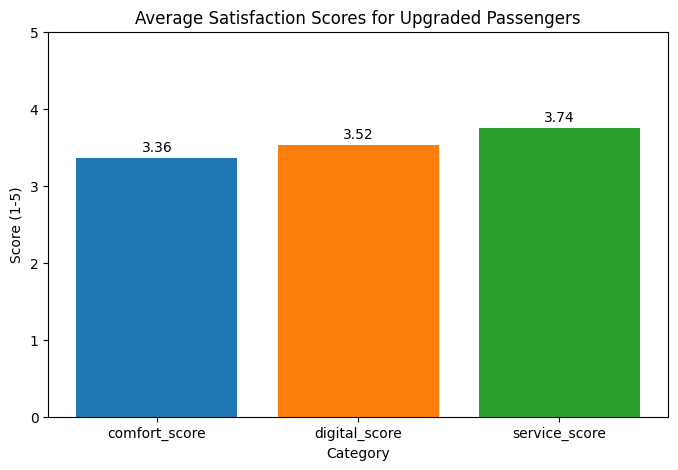

'\nInsight:\n- Passengers who received an upgrade have higher satisfaction across all categories.\n- The largest improvement is in comfort (3.36), followed by digital experience and service.\n- This suggests upgrades positively impact passenger perception of comfort, digital services, and overall service quality.\n'

In [52]:
df['comfort_score'] = df[['Seat comfort','Leg room service','Inflight entertainment']].mean(axis=1)
df['digital_score'] = df[['Online boarding','Online support','Inflight wifi service','Ease of Online booking']].mean(axis=1)
df['service_score'] = df[['On-board service','Baggage handling','Cleanliness']].mean(axis=1)

mean_scores = df.groupby('upgrade')[['comfort_score','digital_score','service_score']].mean()

# Select only upgrade = 1
upgrade_scores = mean_scores.loc[1]

# Plot
plt.figure(figsize=(8,5))
bars = plt.bar(upgrade_scores.index, upgrade_scores.values, color=['#1f77b4','#ff7f0e','#2ca02c'])
plt.ylim(0, 5)  # assuming scores are out of 5
plt.title('Average Satisfaction Scores for Upgraded Passengers')
plt.ylabel('Score (1-5)')
plt.xlabel('Category')

# Add value labels on top
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, f'{yval:.2f}', ha='center', va='bottom')

plt.show()

"""
Insight:
- Passengers who received an upgrade have higher satisfaction across all categories.
- The largest improvement is in comfort (3.36), followed by digital experience and service.
- This suggests upgrades positively impact passenger perception of comfort, digital services, and overall service quality.
"""

Airlines should enhance digital and onboard service touchpoints, emphasizing online support, ease of booking, and cabin service quality. They should target business and long-haul travelers with premium perks, WiFi stability, and loyalty incentives, while offering flexible, low-cost upgrade options for personal travelers. Additionally, highlighting comfort benefits such as legroom, inflight entertainment, and cabin amenities can further encourage upgrades, especially on long-haul flights.